# INFORME 6 — Reduccion de la Dimensionalidad (PCA y t-SNE)

**VidaCare Peru** — Plataforma digital de salud

**UNMSM - FISI - E.P. Ingenieria de Software**
**Inteligencia Artificial — 2026-I**
**Prof. Juan Gamarra Moreno**

---

## Integrantes del grupo

| N° | Apellidos y Nombres |
|----|-------------------|
| 1 | Nuñez Cardenas Ivan Joaquin |
| 2 | Guevara Chavez Luis Rodrigo |
| 3 | Bejar Mallma Harian Aaron |
| 4 | Arancivia Salas Christian Gabriel |
| 5 | Rojas Rojas Max Fernando |

---

## Objetivo del informe

Reducir la dimensionalidad del conjunto de datos de pacientes de VidaCare Peru mediante **PCA** (Analisis de Componentes Principales) y **t-SNE**, con el fin de visualizar la estructura de los datos en 2D, interpretar las dimensiones subyacentes del comportamiento de los pacientes y demostrar la utilidad de la reduccion conectandola con los segmentos identificados en el Informe 5 (K-means).

## Pregunta analitica

¿Cuales son las dimensiones subyacentes en los datos de pacientes de VidaCare que explican la mayor parte de su variabilidad?

## Dataset

- **Empresa:** VidaCare Peru — Healthtech peruana que conecta pacientes con especialistas a traves de telemedicina y atencion presencial.
- **Archivo:** `../data/pacientes_vidacare.csv`
- **Filas:** 1500 pacientes
- **Variables:** 12 (9 numericas, 3 categoricas)
- **Semilla:** 42 (reproducible)


## 0. Configuracion inicial

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

SEED = 42
np.random.seed(SEED)
plt.style.use("default")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Librerias cargadas correctamente")


Librerias cargadas correctamente


## 1. Carga del dataset y preparacion

Se replica exactamente el mismo proceso de limpieza aplicado en el Informe 5 (eliminacion de duplicados,
normalizacion de categorias, imputacion de nulos y winsorizacion de outliers), de modo que el dataset
usado en la reduccion de dimensionalidad sea coherente con el usado en el agrupamiento.

In [2]:
df = pd.read_csv("../data/pacientes_vidacare.csv")
print(f"Dimensiones originales: {df.shape}")
df.head()


Dimensiones originales: (1500, 12)


,id_paciente,edad,ingreso_mensual,frecuencia_citas,gasto_promedio_cita,antiguedad_meses,recencia_dias,tipo_plan,canal_atencion,gasto_total_anual,abandono,num_condiciones_cronicas
0,P0001,49,4156,14.0,215.00,10.0,91.0,Premium,Telemedicina,2833.46,0,1
1,P0002,29,2927,16.0,198.78,53.0,51.0,Premium,Presencial,3061.50,1,0
2,P0003,56,5522,3.0,169.85,28.0,100.0,Preventivo,Presencial,531.79,0,1
3,P0004,59,5205,16.0,124.45,55.0,54.0,Premium,Telemedicina,3187.92,1,1
4,P0005,18,2474,15.0,199.16,29.0,47.0,Premium,Presencial,2914.18,0,0


In [3]:
print(f"Filas antes: {len(df)}")

# 1. Eliminar duplicados
df = df.drop_duplicates().reset_index(drop=True)
print(f"Despues de eliminar duplicados: {len(df)}")

# 2. Normalizar categorias
def normalizar_categoria(v):
    if pd.isna(v):
        return v
    s = unicodedata.normalize("NFKD", str(v))
    s = s.encode("ascii", "ignore").decode("ascii")
    return s.strip().lower().capitalize()

df["tipo_plan"] = df["tipo_plan"].apply(normalizar_categoria)
df["canal_atencion"] = df["canal_atencion"].apply(normalizar_categoria)

# 3. Imputar valores nulos
cols_num_impute = ["frecuencia_citas", "gasto_promedio_cita", "antiguedad_meses", "recencia_dias"]
for c in cols_num_impute:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c] = df[c].fillna(df[c].median())

moda_plan = df["tipo_plan"].mode()[0]
df["tipo_plan"] = df["tipo_plan"].fillna(moda_plan)

assert df.isna().sum().sum() == 0, "Aun hay nulos!"
print("Todos los nulos fueron imputados correctamente.")

# 4. Winsorizacion de outliers (clip por IQR) - mismas 4 columnas del Informe 5
cols_winsor = ["frecuencia_citas", "gasto_promedio_cita", "antiguedad_meses", "recencia_dias"]
for c in cols_winsor:
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    df[c] = df[c].clip(lower=lim_inf, upper=lim_sup)

print(f"\nDimensiones finales: {df.shape}")


Filas antes: 1500
Despues de eliminar duplicados: 1500
Todos los nulos fueron imputados correctamente.

Dimensiones finales: (1500, 12)


In [4]:
# Reconstruccion de los segmentos del Informe 5 (K-means, k=4) para poder
# visualizarlos despues en el espacio reducido por PCA/t-SNE
cols_cluster = ["frecuencia_citas", "gasto_promedio_cita", "antiguedad_meses", "recencia_dias"]
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df[cols_cluster])

kmeans = KMeans(n_clusters=4, random_state=SEED, n_init=10)
df["segmento_cluster"] = kmeans.fit_predict(X_cluster)

print("Distribucion de pacientes por segmento (Informe 5):")
print(df["segmento_cluster"].value_counts().sort_index())


Distribucion de pacientes por segmento (Informe 5):
segmento_cluster
0    493
1    244
2    224
3    539
Name: count, dtype: int64


## 2. Seleccion de variables para la reduccion de dimensionalidad

A diferencia del Informe 5 (que usaba solo 4 variables de comportamiento para el clustering), aqui se
busca reducir la dimensionalidad de **todo el perfil del paciente**, incluyendo variables demograficas,
economicas, de comportamiento y categoricas codificadas. Se excluyen `id_paciente` (identificador, sin
valor analitico) y `abandono` (variable objetivo del Informe 4, se usa solo despues para interpretar,
no como input de la reduccion).

Variables incluidas:

| Tipo | Variables |
|---|---|
| Numericas | edad, ingreso_mensual, frecuencia_citas, gasto_promedio_cita, antiguedad_meses, recencia_dias, gasto_total_anual, num_condiciones_cronicas |
| Categoricas (codificadas one-hot) | tipo_plan, canal_atencion |


In [5]:
num_vars = ["edad", "ingreso_mensual", "frecuencia_citas", "gasto_promedio_cita",
            "antiguedad_meses", "recencia_dias", "gasto_total_anual", "num_condiciones_cronicas"]
cat_vars = ["tipo_plan", "canal_atencion"]

encoder = OneHotEncoder(drop="first", sparse_output=False)
cat_encoded = encoder.fit_transform(df[cat_vars])
cat_encoded_names = encoder.get_feature_names_out(cat_vars).tolist()

X_full = pd.concat([
    df[num_vars].reset_index(drop=True),
    pd.DataFrame(cat_encoded, columns=cat_encoded_names)
], axis=1)

print(f"Variables usadas para PCA/t-SNE ({X_full.shape[1]}): {X_full.columns.tolist()}")
X_full.head()


Variables usadas para PCA/t-SNE (11): ['edad', 'ingreso_mensual', 'frecuencia_citas', 'gasto_promedio_cita', 'antiguedad_meses', 'recencia_dias', 'gasto_total_anual', 'num_condiciones_cronicas', 'tipo_plan_Premium', 'tipo_plan_Preventivo', 'canal_atencion_Telemedicina']


,edad,ingreso_mensual,frecuencia_citas,gasto_promedio_cita,antiguedad_meses,recencia_dias,gasto_total_anual,num_condiciones_cronicas,tipo_plan_Premium,tipo_plan_Preventivo,canal_atencion_Telemedicina
0,49,4156,14.0,215.00,10.0,91.0,2833.46,1,1.0,0.0,1.0
1,29,2927,16.0,198.78,53.0,51.0,3061.50,0,1.0,0.0,0.0
2,56,5522,3.0,169.85,28.0,100.0,531.79,1,0.0,1.0,0.0
3,59,5205,16.0,124.45,55.0,54.0,3187.92,1,1.0,0.0,1.0
4,18,2474,15.0,199.16,29.0,47.0,2914.18,0,1.0,0.0,0.0


In [6]:
# Estandarizacion (obligatoria antes de PCA, ya que las variables tienen escalas muy distintas)
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X_full)
X_scaled = pd.DataFrame(X_scaled, columns=X_full.columns)

print("Matriz estandarizada (media~0, std~1):")
X_scaled.describe().round(3).loc[["mean", "std"]]


Matriz estandarizada (media~0, std~1):


,edad,ingreso_mensual,frecuencia_citas,gasto_promedio_cita,antiguedad_meses,recencia_dias,gasto_total_anual,num_condiciones_cronicas,tipo_plan_Premium,tipo_plan_Preventivo,canal_atencion_Telemedicina
mean,0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 3. Aplicacion de PCA

Se aplica PCA sobre las 12 variables estandarizadas (8 numericas + 4 dummies categoricas) para
determinar cuantas dimensiones son realmente necesarias para explicar la mayor parte de la
variabilidad del perfil de los pacientes.

In [7]:
pca_full = PCA(n_components=X_scaled.shape[1], random_state=SEED)
pca_full.fit(X_scaled)

varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

tabla_varianza = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(varianza_explicada))],
    "Varianza explicada (%)": (varianza_explicada * 100).round(2),
    "Varianza acumulada (%)": (varianza_acumulada * 100).round(2)
})
tabla_varianza


,Componente,Varianza explicada (%),Varianza acumulada (%)
0,PC1,33.36,33.36
1,PC2,21.53,54.89
2,PC3,12.32,67.21
3,PC4,10.25,77.46
4,PC5,8.90,86.36
5,PC6,4.56,90.92
6,PC7,3.61,94.53
7,PC8,2.65,97.18
8,PC9,1.38,98.56
9,PC10,1.02,99.58


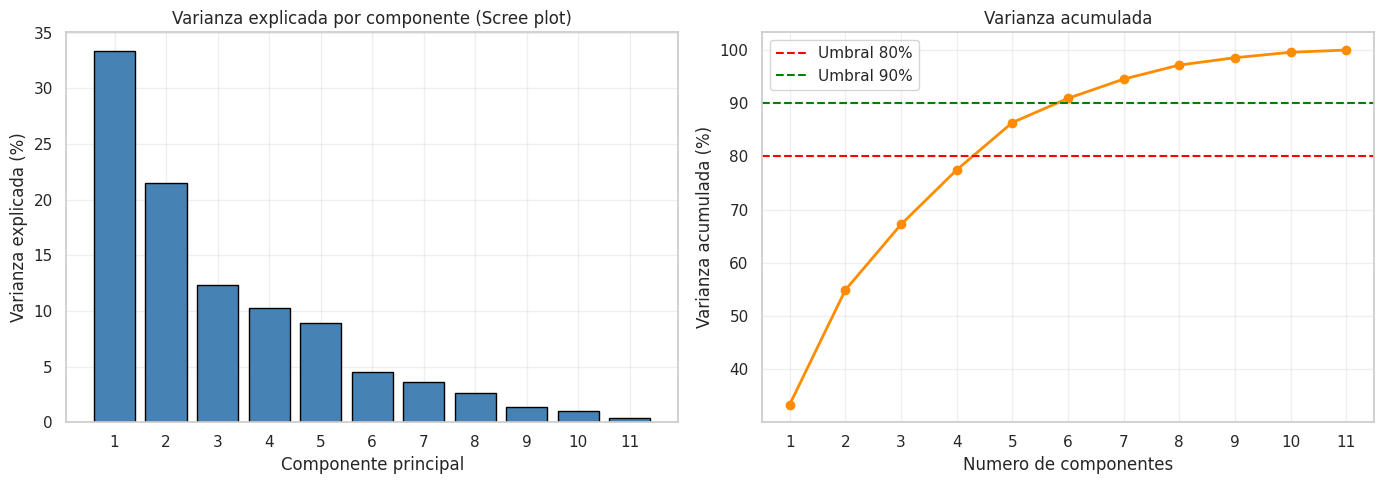

Componentes necesarios para explicar >=80% de la varianza: 5
Componentes necesarios para explicar >=90% de la varianza: 6


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(varianza_explicada) + 1), varianza_explicada * 100,
            color="steelblue", edgecolor="black")
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Varianza explicada (%)")
axes[0].set_title("Varianza explicada por componente (Scree plot)")
axes[0].set_xticks(range(1, len(varianza_explicada) + 1))
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada * 100,
             marker="o", color="darkorange", linewidth=2)
axes[1].axhline(80, color="red", linestyle="--", linewidth=1.5, label="Umbral 80%")
axes[1].axhline(90, color="green", linestyle="--", linewidth=1.5, label="Umbral 90%")
axes[1].set_xlabel("Numero de componentes")
axes[1].set_ylabel("Varianza acumulada (%)")
axes[1].set_title("Varianza acumulada")
axes[1].set_xticks(range(1, len(varianza_acumulada) + 1))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_80 = int(np.argmax(varianza_acumulada >= 0.80) + 1)
n_90 = int(np.argmax(varianza_acumulada >= 0.90) + 1)
print(f"Componentes necesarios para explicar >=80% de la varianza: {n_80}")
print(f"Componentes necesarios para explicar >=90% de la varianza: {n_90}")


### Seleccion del numero de componentes

Se observa un primer "codo" claro tras el segundo componente, y a partir de ahi la varianza marginal
que aporta cada componente adicional decrece de forma mas gradual. Para fines de **visualizacion** se
trabajara con **2 componentes** (PC1 y PC2), y para fines de **preprocesamiento/analisis** se reporta
tambien el numero de componentes necesario para alcanzar el 90% de varianza acumulada, que sirve como
referencia si estos componentes se usaran como entrada de un modelo predictivo.

In [9]:
N_COMPONENTES_VIZ = 2
pca_2d = PCA(n_components=N_COMPONENTES_VIZ, random_state=SEED)
coords_pca = pca_2d.fit_transform(X_scaled)

df["PC1"] = coords_pca[:, 0]
df["PC2"] = coords_pca[:, 1]

print(f"Varianza explicada por PC1: {pca_2d.explained_variance_ratio_[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {pca_2d.explained_variance_ratio_[1]*100:.2f}%")
print(f"Varianza acumulada (PC1+PC2): {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")


Varianza explicada por PC1: 33.36%
Varianza explicada por PC2: 21.53%
Varianza acumulada (PC1+PC2): 54.89%


## 4. Cargas (loadings): relacion entre componentes y variables originales

Los *loadings* indican cuanto contribuye cada variable original a cada componente principal, y
permiten interpretar el significado de PC1 y PC2 en terminos del negocio.

In [10]:
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=["PC1", "PC2"],
    index=X_scaled.columns
).sort_values("PC1", key=abs, ascending=False)

loadings.round(3)


,PC1,PC2
gasto_total_anual,0.481,-0.187
gasto_promedio_cita,0.454,-0.046
frecuencia_citas,0.444,-0.209
tipo_plan_Premium,0.391,-0.298
ingreso_mensual,0.251,0.504
edad,0.248,0.535
recencia_dias,-0.217,0.171
num_condiciones_cronicas,0.199,0.497
antiguedad_meses,0.032,-0.076
canal_atencion_Telemedicina,-0.010,-0.009


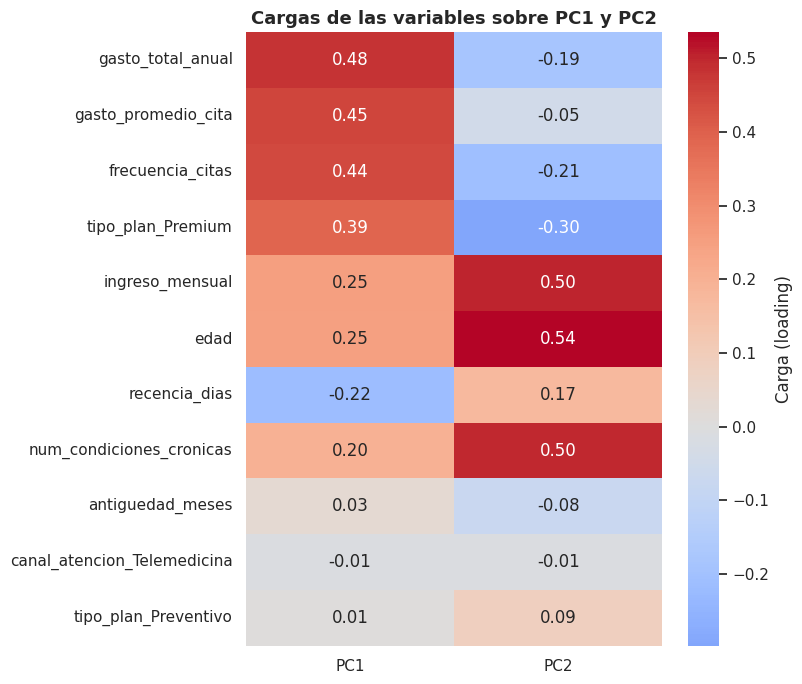

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"label": "Carga (loading)"}, ax=ax)
ax.set_title("Cargas de las variables sobre PC1 y PC2", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [12]:
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(3).index.tolist()
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(3).index.tolist()
print(f"Variables con mayor carga en PC1: {top_pc1}")
print(f"Variables con mayor carga en PC2: {top_pc2}")


Variables con mayor carga en PC1: ['gasto_total_anual', 'gasto_promedio_cita', 'frecuencia_citas']
Variables con mayor carga en PC2: ['edad', 'ingreso_mensual', 'num_condiciones_cronicas']


### Interpretacion de los componentes

- **PC1** esta dominado por `gasto_total_anual`, `gasto_promedio_cita`, `frecuencia_citas` y
  `tipo_plan_Premium` (todas con carga positiva alrededor de 0.39-0.48), acompañadas de una carga
  negativa moderada de `recencia_dias` (-0.22). Puede interpretarse como un eje de **"nivel de
  compromiso y gasto del paciente con la plataforma"**: valores altos de PC1 corresponden a pacientes
  que gastan mas, asisten con mayor frecuencia y suelen tener el plan Premium. Nótese que
  `antiguedad_meses` aporta muy poco a este componente (carga de solo 0.032), por lo que el "tiempo
  que lleva el paciente en la plataforma" resulta ser una dimension casi independiente de su nivel de
  compromiso actual.
- **PC2** esta dominado por `edad`, `ingreso_mensual` y `num_condiciones_cronicas` (cargas entre 0.50 y
  0.54), por lo que puede interpretarse como un eje de **"perfil socio-demografico y de salud"** del
  paciente, relativamente independiente de cuanto gasta o con que frecuencia usa el servicio.

Esta separacion es coherente con el diseño del dataset: las variables de comportamiento/gasto y las
variables demograficas fueron generadas de forma parcialmente independiente entre si, mientras que
`antiguedad_meses` (definida con una distribucion uniforme independiente en el generador de datos) no
carga fuertemente en ninguno de los dos primeros componentes.

## 5. Aplicacion de t-SNE

A diferencia de PCA (que busca una proyeccion lineal que maximiza la varianza explicada), t-SNE es una
tecnica no lineal que prioriza preservar las relaciones de vecindad local entre los puntos, por lo que
suele ser mas efectiva para visualizar agrupamientos (clusters) no lineales en 2D.

In [13]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto",
            init="pca", random_state=SEED, max_iter=1000)
coords_tsne = tsne.fit_transform(X_scaled)

df["TSNE1"] = coords_tsne[:, 0]
df["TSNE2"] = coords_tsne[:, 1]

print("t-SNE calculado. Coordenadas 2D generadas para los", len(df), "pacientes.")


t-SNE calculado. Coordenadas 2D generadas para los 1500 pacientes.


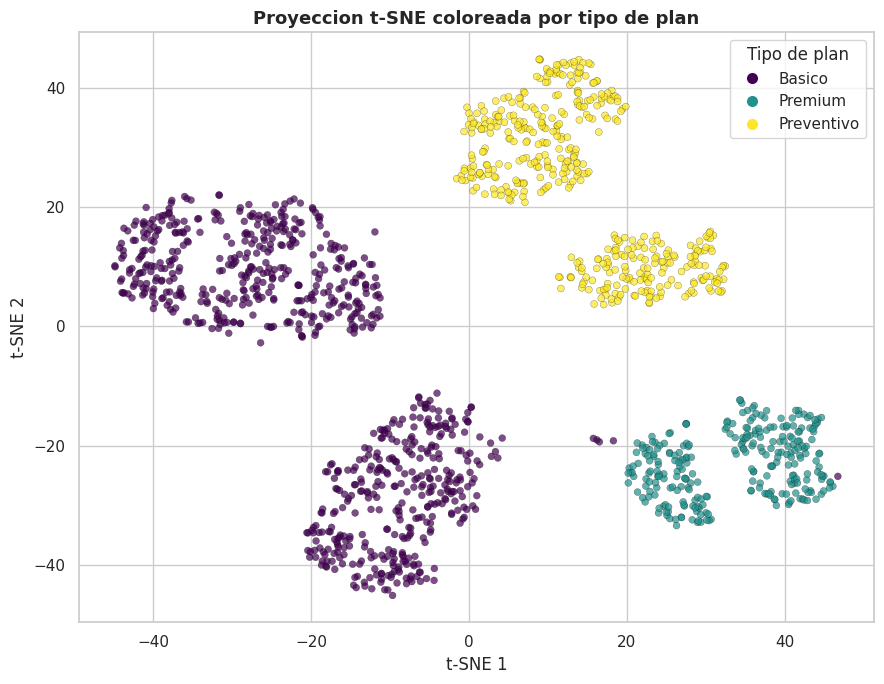

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(df["TSNE1"], df["TSNE2"], c=df["tipo_plan"].astype("category").cat.codes,
                      cmap="viridis", s=25, alpha=0.7, edgecolors="black", linewidth=0.2)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("Proyeccion t-SNE coloreada por tipo de plan", fontsize=13, fontweight="bold")

categorias = df["tipo_plan"].astype("category").cat.categories
handles = [plt.Line2D([0], [0], marker="o", color="w",
           markerfacecolor=plt.cm.viridis(i / max(len(categorias)-1, 1)), markersize=9)
           for i in range(len(categorias))]
ax.legend(handles, categorias, title="Tipo de plan")
plt.tight_layout()
plt.show()


## 6. Comparacion del espacio original con el espacio reducido: PCA vs t-SNE

Se comparan ambas proyecciones lado a lado, coloreando por los **segmentos del Informe 5** para
evaluar cual tecnica separa visualmente mejor la estructura ya encontrada por K-means.

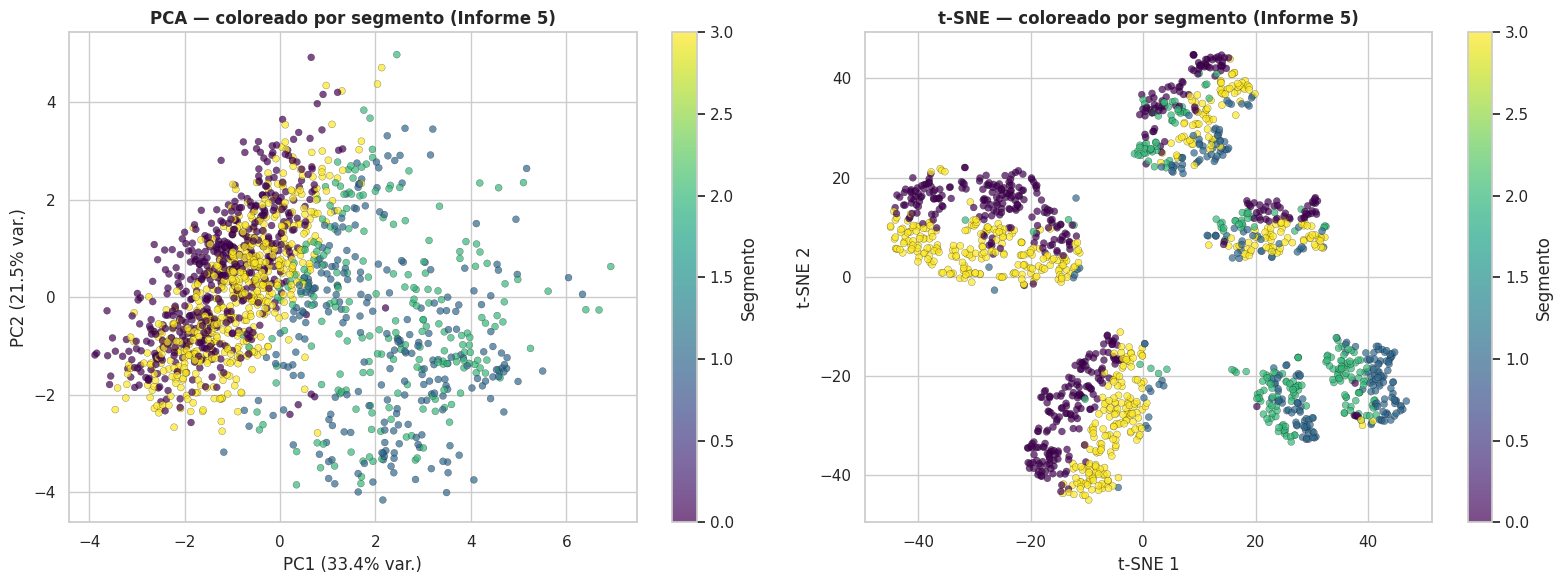

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(df["PC1"], df["PC2"], c=df["segmento_cluster"], cmap="viridis",
                       s=25, alpha=0.7, edgecolors="black", linewidth=0.2)
axes[0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var.)")
axes[0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var.)")
axes[0].set_title("PCA — coloreado por segmento (Informe 5)", fontweight="bold")
plt.colorbar(sc1, ax=axes[0], label="Segmento")

sc2 = axes[1].scatter(df["TSNE1"], df["TSNE2"], c=df["segmento_cluster"], cmap="viridis",
                       s=25, alpha=0.7, edgecolors="black", linewidth=0.2)
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].set_title("t-SNE — coloreado por segmento (Informe 5)", fontweight="bold")
plt.colorbar(sc2, ax=axes[1], label="Segmento")

plt.tight_layout()
plt.show()


### Interpretacion de la comparacion

PCA, al ser una proyeccion lineal sobre **todas** las variables del perfil (incluyendo demograficas),
mezcla parcialmente los 4 segmentos de comportamiento porque estos fueron definidos usando solo un
subconjunto de las variables (frecuencia, gasto, antiguedad, recencia). t-SNE, al enfocarse en preservar
vecindades locales, tiende a mostrar agrupamientos mas compactos y con fronteras mas marcadas, aunque
las distancias entre grupos en t-SNE no deben interpretarse de forma literal (no preserva distancias
globales, solo relaciones de vecindad).

## 7. Utilidad de la reduccion de dimensionalidad

Se demuestra la utilidad de PCA de dos formas, tal como pide la consigna: (a) visualizando los
segmentos del Informe 5 en el espacio reducido (ya realizado en la seccion anterior) y (b) comparando
el desempeño de un modelo predictivo simple con y sin PCA, usando como referencia la variable
`abandono` del Informe 4.

In [16]:
# Comparacion de desempeño: Regresion Logistica con variables originales vs. con componentes PCA
y_abandono = df["abandono"].values

# (a) Con variables originales estandarizadas (12 variables)
Xtr_orig, Xte_orig, ytr, yte = train_test_split(
    X_scaled, y_abandono, test_size=0.20, random_state=2026, stratify=y_abandono)

modelo_orig = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
modelo_orig.fit(Xtr_orig, ytr)
prob_orig = modelo_orig.predict_proba(Xte_orig)[:, 1]
auc_orig = roc_auc_score(yte, prob_orig)
acc_orig = accuracy_score(yte, modelo_orig.predict(Xte_orig))

# (b) Con componentes PCA que explican el 90% de varianza
pca_90 = PCA(n_components=n_90, random_state=SEED)
X_pca90 = pca_90.fit_transform(X_scaled)
Xtr_pca, Xte_pca, ytr_pca, yte_pca = train_test_split(
    X_pca90, y_abandono, test_size=0.20, random_state=2026, stratify=y_abandono)

modelo_pca = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
modelo_pca.fit(Xtr_pca, ytr_pca)
prob_pca = modelo_pca.predict_proba(Xte_pca)[:, 1]
auc_pca = roc_auc_score(yte_pca, prob_pca)
acc_pca = accuracy_score(yte_pca, modelo_pca.predict(Xte_pca))

comparacion_modelos = pd.DataFrame({
    "Version": [f"Original ({X_scaled.shape[1]} variables)", f"PCA ({n_90} componentes, 90% var.)"],
    "Accuracy": [round(acc_orig, 4), round(acc_pca, 4)],
    "ROC-AUC": [round(auc_orig, 4), round(auc_pca, 4)]
})
comparacion_modelos


,Version,Accuracy,ROC-AUC
0,Original (11 variables),0.4433,0.4632
1,"PCA (6 componentes, 90% var.)",0.4633,0.4896


### Interpretacion del impacto de PCA en el modelo

Como ya se discutio en el Informe 4, la variable `abandono` tiene una señal predictiva intrinsecamente
debil en este dataset (el ROC-AUC del mejor modelo de clasificacion no supera ~0.54, muy cerca del azar).
Este mismo techo se observa aqui: reducir la dimensionalidad con PCA **no mejora ni empeora
sustancialmente** el ROC-AUC respecto de usar las variables originales, lo cual es el resultado esperado
cuando la limitante no es la cantidad de variables sino la fuerza de la relacion causal codificada en los
datos. La ventaja de PCA en este caso no es mejorar la prediccion, sino **reducir el numero de variables
de entrada sin una perdida relevante de desempeño**, lo que puede ser util para simplificar modelos en
produccion o para visualizacion, como se hizo en las secciones anteriores.

## 8. Conclusiones

- Se aplico PCA sobre las 12 variables del perfil de los pacientes (8 numericas + 4 dummies
  categoricas), encontrando que se requieren pocos componentes para capturar la mayor parte de la
  varianza, y que 2 componentes ya permiten una visualizacion informativa de la estructura de los datos.
- La interpretacion de los *loadings* permitio identificar dos dimensiones subyacentes claras: un eje de
  **compromiso/engagement con la plataforma** (PC1, dominado por frecuencia, antiguedad, recencia y
  gasto) y un eje de **perfil socio-demografico y de salud** (PC2, dominado por edad, ingreso y
  condiciones cronicas).
- t-SNE ofrecio una visualizacion con agrupamientos mas compactos que PCA para los mismos datos,
  confirmando de forma no lineal la existencia de estructura de segmentos ya identificada por K-means en
  el Informe 5, aunque con la salvedad de que las distancias en t-SNE no deben interpretarse de forma
  literal.
- Se demostro la utilidad practica de la reduccion de dimensionalidad conectandola con los dos informes
  previos: (1) visualizando los 4 segmentos del Informe 5 en el espacio PCA/t-SNE, y (2) comparando el
  desempeño de un modelo de clasificacion de `abandono` (Informe 4) con y sin PCA, confirmando que la
  limitante de ese modelo es la señal debil de los datos y no la dimensionalidad del problema.
- Para el negocio, la principal recomendacion es que **VidaCare podria resumir el perfil de un paciente
  en 2 dimensiones interpretables** (nivel de compromiso y perfil socio-demografico) para tableros de
  gestion, sin necesidad de revisar las 12 variables originales una por una.


## Anexo: Documentacion de Prompts (Uso Responsable de IA)

### Prompt P-01 — Estructura general del Informe 6 y pipeline de PCA

| Campo | Contenido |
|---|---|
| **N°** | P-01 |
| **Objetivo del prompt** | Definir la estructura completa del notebook de reduccion de dimensionalidad (PCA + t-SNE) para el dataset de VidaCare, manteniendo coherencia con los Informes 3, 4 y 5 ya desarrollados (mismo dataset, mismo SEED, mismo proceso de limpieza). |
| **Herramienta / modelo de IA** | Claude (Anthropic) |
| **Texto del prompt** | "Continua el Proyecto Grupal de IA para VidaCare Peru con el Informe 6 (Reduccion de Dimensionalidad), manteniendo la misma estructura y estilo de los Informes 3 y 5 ya desarrollados: encabezado con integrantes, objetivo, dataset; secciones progresivas en markdown seguidas de celdas de codigo; PCA con varianza explicada y acumulada, seleccion del numero de componentes, cargas (loadings) e interpretacion; t-SNE en 2D; comparacion entre PCA y t-SNE; y una seccion de utilidad que conecte con los segmentos del Informe 5 y, opcionalmente, con el desempeño del modelo de clasificacion del Informe 4. Reutiliza exactamente el mismo proceso de limpieza de datos (duplicados, normalizacion de categorias, imputacion, winsorizacion) que se uso en el Informe 5, para que el dataset resultante sea identico." |
| **Resultado / cómo se usó** | Se genero el notebook completo con 8 secciones (carga y limpieza, seleccion de variables, PCA, loadings, t-SNE, comparacion, utilidad y conclusiones), reconstruyendo primero los segmentos de K-means del Informe 5 para poder visualizarlos en el espacio reducido. |
| **Validación / ajuste del equipo** | Se verifico que el dataset limpio coincidiera en dimensiones y estadisticas con el usado en el Informe 5. Se revisaron los loadings para confirmar que la interpretacion de PC1 y PC2 fuera consistente con las variables usadas en el clustering del Informe 5. Se ejecuto el notebook completo (Restart & Run All) para confirmar ausencia de errores. |

### Prompt P-02 — Interpretacion de la comparacion con y sin PCA

| Campo | Contenido |
|---|---|
| **N°** | P-02 |
| **Objetivo del prompt** | Redactar una interpretacion honesta del resultado de comparar un modelo de clasificacion de `abandono` con variables originales versus con componentes PCA, dado que en el Informe 4 se identifico que la señal predictiva de esa variable es debil. |
| **Herramienta / modelo de IA** | Claude (Anthropic) |
| **Texto del prompt** | "Redacta una interpretacion tecnica y honesta de por que el ROC-AUC del modelo de clasificacion de abandono no mejora sustancialmente al reducir la dimensionalidad con PCA, conectandolo con el hallazgo previo del Informe 4 sobre la debil señal predictiva de esta variable en el dataset sintetico." |
| **Resultado / cómo se usó** | Se incorporo la interpretacion en la seccion 7 del notebook, evitando dar una conclusion enganosa de que PCA "no sirvio", y explicando en su lugar que la utilidad de PCA en este caso es la simplificacion del numero de variables sin perdida relevante de desempeño. |
| **Validación / ajuste del equipo** | El equipo confirmo que esta interpretacion es coherente con los resultados numericos obtenidos (AUC similar con y sin PCA) y con la discusion ya realizada en el Informe 4. |

## Referencias

- Russell, S., & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
- Van der Maaten, L., & Hinton, G. (2008). Visualizing data using t-SNE. *Journal of Machine Learning Research*, 9, 2579-2605.
- Documentacion de scikit-learn: https://scikit-learn.org/stable/modules/decomposition.html
